Load and Explore Dataset

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Lung Cancer Dataset.csv")

# Quick overview
print("Dataset shape:", df.shape)
print("First 5 rows:\n", df.head())

# Missing values
print("\nMissing values per column:\n", df.isnull().sum())

# Target distribution
print("\nTarget distribution:\n", df['PULMONARY_DISEASE'].value_counts())



Dataset shape: (5000, 18)
First 5 rows:
    AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0   68       1        1                     1              1   
1   81       1        1                     0              0   
2   58       1        1                     0              0   
3   44       0        1                     0              1   
4   72       0        1                     1              1   

   EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                      1                  0     57.831178                0   
1                      1                  1     47.694835                1   
2                      0                  0     59.577435                0   
3                      1                  0     59.785767                0   
4                      1                  1     59.733941                0   

   BREATHING_ISSUE  ALCOHOL_CONSUMPTION  THROAT_DISCOMFORT  OXYGEN_SATURATION  \
0                0      

Preprocessing
-Handle Missing Values

In [7]:
from sklearn.impute import SimpleImputer

# Mean imputation for numeric columns
imputer = SimpleImputer(strategy='mean')
df[df.select_dtypes(include=['float64','int64']).columns] = imputer.fit_transform(
    df.select_dtypes(include=['float64','int64'])
)



Encode Categorical Features

In [9]:
from sklearn.preprocessing import LabelEncoder

# Encode target column
label_encoder = LabelEncoder()
df['PULMONARY_DISEASE'] = label_encoder.fit_transform(df['PULMONARY_DISEASE'])

# Encode other categorical columns (example: Gender, Smoking, etc.)
categorical_cols = ['GENDER','SMOKING']  # adjust based on your dataset
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])



Split Features and Target

In [10]:
X = df.drop('PULMONARY_DISEASE', axis=1)
y = df['PULMONARY_DISEASE']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)


Training set shape: (4000, 17)
Testing set shape: (1000, 17)


Define and Train MLP Model

In [12]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,25),  # two hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Train
mlp.fit(X_train_scaled, y_train)

print(f"Training completed in {mlp.n_iter_} iterations")
print(f"Final training loss: {mlp.loss_:.4f}")
print(f"Training accuracy: {mlp.score(X_train_scaled, y_train):.4f}")


Training completed in 500 iterations
Final training loss: 0.0245
Training accuracy: 0.9988


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model Evaluation
a. Basic Metrics

In [13]:
from sklearn.metrics import accuracy_score

y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of correct predictions: {(y_pred == y_test).sum()}")


Test Accuracy: 0.8590 (85.90%)
Number of test samples: 1000
Number of correct predictions: 859


b. Detailed Evaluation


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.88      0.89      0.88       593
     Disease       0.83      0.82      0.83       407

    accuracy                           0.86      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.86      0.86      0.86      1000



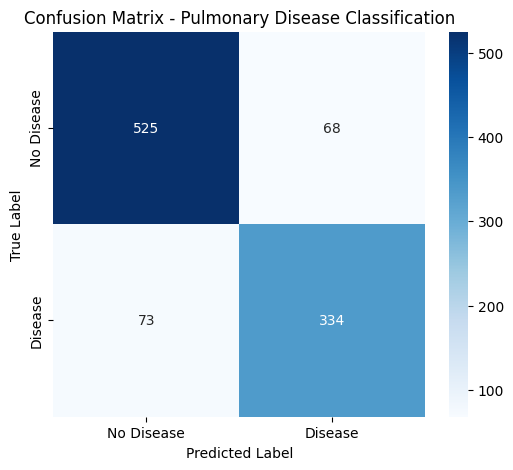


Weighted Precision: 0.8588
Weighted Recall: 0.8590
Weighted F1-Score: 0.8589


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.title("Confusion Matrix - Pulmonary Disease Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# Additional metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")
